<a href="https://colab.research.google.com/github/fvelascor/MCDIA/blob/master/Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_Estad%C3%ADstico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

# PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO

## Objetivo

En este proyecto se realizará un análisis estadístico utilizando el dataset `mpg` de la librería Seaborn.

El objetivo es aplicar:
- análisis descriptivo,
- limpieza básica de datos,
- análisis de correlación,
- y aprendizaje estadístico mediante regresión lineal simple.

Se buscará comprender la relación entre la potencia de un automóvil (`horsepower`) y su rendimiento de combustible (`mpg`).

📥 Importar **librerías**

In [31]:
# Importar librerías

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# Carga del Dataset

Se utilizará el dataset `mpg` incluido en la librería Seaborn.

Este dataset contiene información sobre automóviles, incluyendo:
- consumo de combustible,
- potencia,
- peso,
- aceleración,
- entre otras variables relevantes.

In [32]:
# Importar dataset

df = sns.load_dataset("mpg")

# Visualizar primeros registros

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


# Exploración Inicial del Dataset

Antes de comenzar el análisis, es importante conocer:
- la estructura del dataset,
- los tipos de datos,
- y la existencia de valores nulos.

In [33]:
# Observar estructura general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [34]:
# Verificar valores nulos

df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


# Limpieza Mínima de Datos

Se detectaron valores nulos en algunas variables numéricas.

Debido a que la cantidad de registros faltantes es reducida, se eliminarán utilizando `dropna()` para asegurar consistencia en el análisis y en el modelo de regresión lineal.

In [35]:
# Eliminar registros con valores nulos

df = df.dropna()

In [36]:
# Verificar valores nulos por columna

df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [37]:
# Verificar cantidad final de registros

print("Cantidad de registros:", len(df))

Cantidad de registros: 392


# Análisis Descriptivo

El análisis descriptivo permite comprender:
- tendencias centrales,
- dispersión,
- valores máximos y mínimos,
- y comportamiento general de las variables numéricas.

In [38]:
# Resumen estadístico

df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## Interpretación

Las variables presentan diferentes escalas y niveles de dispersión.

Por ejemplo:
- `horsepower` muestra una dispersión considerable,
- mientras que `mpg` presenta variabilidad relacionada con el tipo de automóvil y su eficiencia de combustible.


# Distribución de la Variable MPG

Se utilizará un histograma para observar la distribución del rendimiento de combustible (`mpg`).

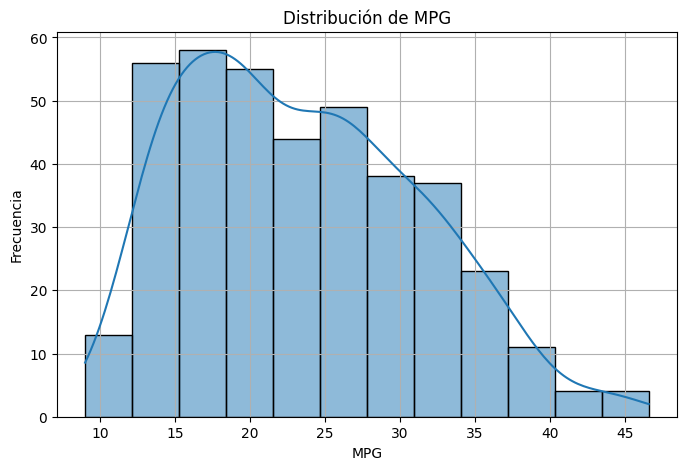

In [39]:
# Visualizar distribución

plt.figure(figsize=(8,5))

sns.histplot(df["mpg"], kde=True)

plt.title("Distribución de MPG")
plt.xlabel("MPG")
plt.ylabel("Frecuencia")

plt.grid(True)

plt.show()

## Interpretación

La distribución de `mpg` permite observar cómo se concentran los valores de rendimiento de combustible dentro del dataset.

El KDE ayuda a identificar la forma general de la distribución.

# Detección de Valores Atípicos

Se utilizará un boxplot para identificar posibles valores atípicos en la variable `horsepower`.

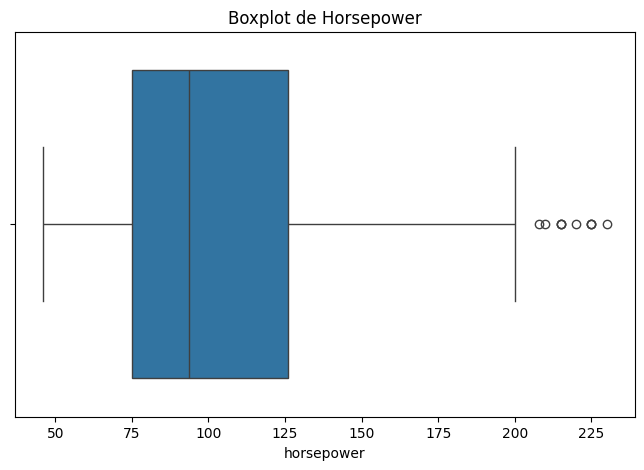

In [40]:
# Visualizar outliers

plt.figure(figsize=(8,5))

sns.boxplot(x=df["horsepower"])

plt.title("Boxplot de Horsepower")

plt.show()

## Interpretación

El boxplot permite identificar valores extremos dentro de la variable `horsepower`.

Estos valores representan automóviles con potencias significativamente diferentes respecto al resto del dataset.

# Análisis de Correlación

La matriz de correlación permite identificar relaciones lineales entre variables numéricas.

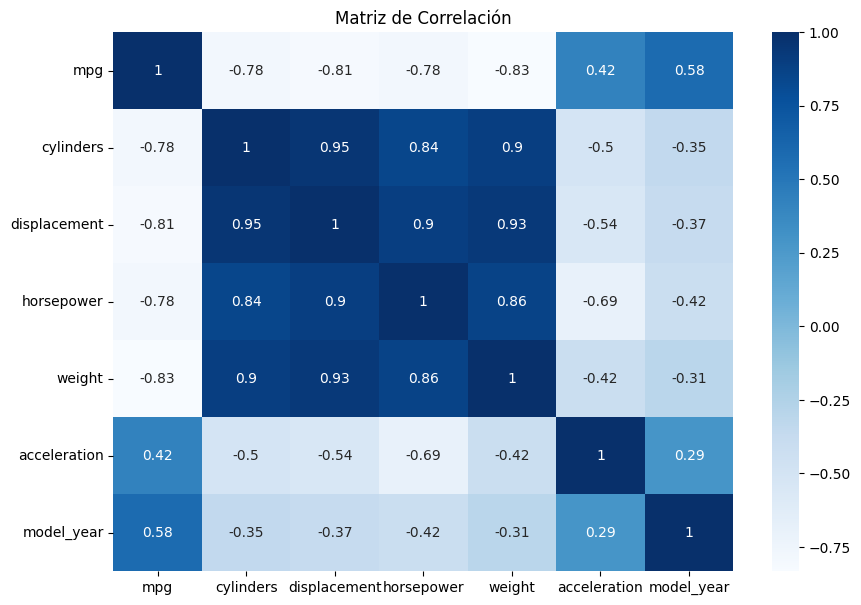

In [41]:
# Calcular correlación

corr = df.corr(numeric_only=True)

# Visualizar heatmap

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap="Blues")

plt.title("Matriz de Correlación")

plt.show()

## Interpretación

Se observa una correlación negativa entre `horsepower` y `mpg`.

Esto indica que los automóviles con mayor potencia tienden a tener menor eficiencia de combustible.




# Regresión Lineal Simple

Se construirá un modelo de regresión lineal simple para predecir el rendimiento de combustible (`mpg`) en función de la potencia (`horsepower`).

In [42]:
# Definir variables predictora y objetivo

X = df[["horsepower"]]

y = df["mpg"]

In [43]:
# Crear modelo

modelo = LinearRegression()

In [44]:
# Entrenar modelo

modelo.fit(X, y)

LinearRegression()

In [45]:
# Realizar predicciones

y_pred = modelo.predict(X)

# Visualización de la Regresión Lineal

Se compararán los datos reales con la recta generada por el modelo de regresión.

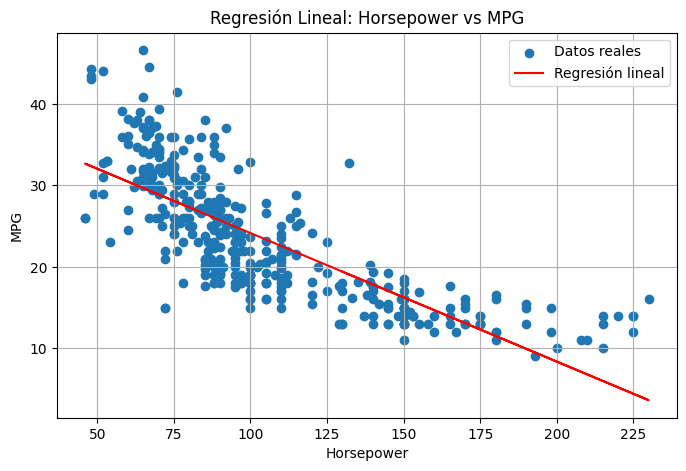

In [46]:
# Visualizar regresión lineal

plt.figure(figsize=(8,5))

plt.scatter(X, y, label="Datos reales")

plt.plot(X, y_pred, color="red", label="Regresión lineal")

plt.title("Regresión Lineal: Horsepower vs MPG")

plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.legend()

plt.grid(True)

plt.show()

## Interpretación

La recta de regresión muestra una tendencia negativa entre `horsepower` y `mpg`.

Conforme aumenta la potencia del automóvil, disminuye el rendimiento de combustible.

# Evaluación del Modelo

Se calcularán métricas básicas para evaluar el desempeño del modelo de regresión lineal.

In [47]:
# Calcular MSE

mse = np.mean((y - y_pred) ** 2)

print("MSE:", mse)

MSE: 23.943662938603108


In [48]:
# Calcular R²

r2 = modelo.score(X, y)

print("R²:", r2)

R²: 0.6059482578894348


## Interpretación

El valor de R² indica qué proporción de la variabilidad de `mpg` puede ser explicada por `horsepower`.

Mientras más cercano a 1 sea el valor de R², mejor será el ajuste del modelo.

# Predicción de Nuevos Valores

Se realizará una predicción utilizando un valor nuevo de `horsepower`.

In [49]:
# Predicción personalizada

nuevo_auto = [[120]]

prediccion = modelo.predict(nuevo_auto)

print("MPG estimado:", prediccion[0])

MPG estimado: 20.99449301873203


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Conclusiones

El análisis descriptivo permitió comprender el comportamiento general del dataset y detectar relaciones relevantes entre variables.

La matriz de correlación mostró una relación negativa entre `horsepower` y `mpg`.

Posteriormente, el modelo de regresión lineal simple permitió modelar dicha relación y generar predicciones sobre el rendimiento de combustible de los automóviles.

En general, el proyecto demuestra cómo aplicar técnicas básicas de análisis estadístico y aprendizaje estadístico utilizando Python y bibliotecas especializadas para ciencia de datos.